---

### eChem course module on:

# [The Hartree–Fock method](https://kthpanor.github.io/echem/hartree-fock/)

### [Patrick Norman](https://www.kth.se/profile/panor)

#### [KTH Royal Institute of Technology](https://www.kth.se/), Stockholm, Sweden

---

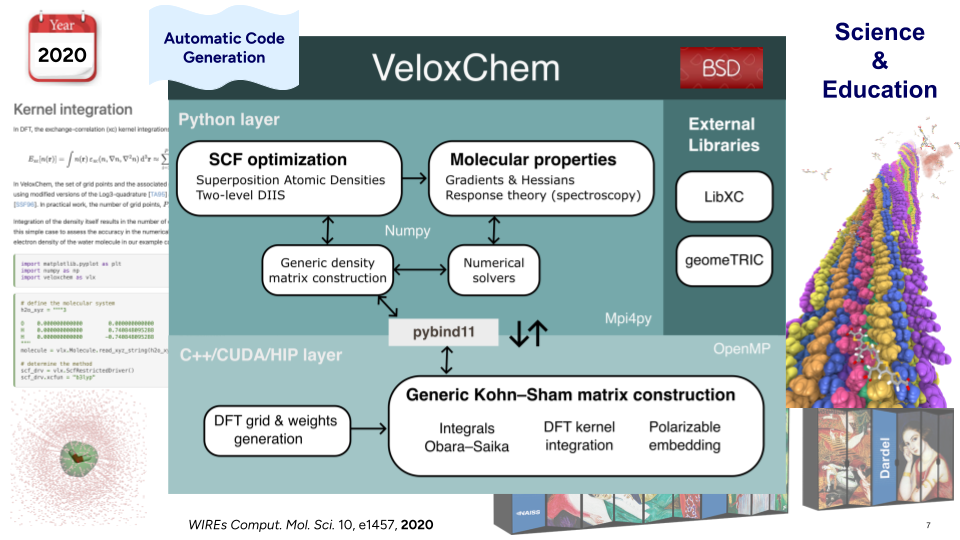

In [ ]:
import numpy as np
import scipy
import veloxchem as vlx

# [Many-electron wave functions](https://kthpanor.github.io/echem/docs/elec_struct/slater.html)

## [Slater determinants](https://kthpanor.github.io/echem/docs/elec_struct/slater.html#slater-determinants)

Many-electron wave functions are constructed as linear combinations of Slater determinants

$$
    | \Psi \rangle =
    |\psi_{1}, \ldots, \psi_{N} \rangle =
    \frac{1}{\sqrt{N!}}
    \begin{vmatrix}
    \psi_{1}(\mathbf{r}_1) & \cdots & \psi_{N}(\mathbf{r}_1) \\
    \vdots & \ddots & \vdots \\
    \psi_{1}(\mathbf{r}_N) & \cdots & \psi_{N}(\mathbf{r}_N) \\
    \end{vmatrix} 
$$

With a set of spin orbitals that spans the one-electron space, the set of all distinct Slater determinants span the $N$-electron space.

### [Spin and molecular orbitals](https://kthpanor.github.io/echem/docs/elec_struct/orbitals.html)

For a system described by a spin-independent Hamiltonian, the spatial and spin degrees of freedom are separable and we arrive at single-electron wave functions, or spin orbitals, of the form

$$
\psi_{p}(\mathbf{r}) = \phi_p(\mathbf{r})
\begin{pmatrix}
1 \\
0
\end{pmatrix} ; \quad
\psi_{\bar{p}}(\mathbf{r}) = \phi_p(\mathbf{r})
\begin{pmatrix}
0 \\
1
\end{pmatrix}
$$

referred to as $\alpha$- and $\beta$-spin orbitals, respectively.

### [Linear combination of atomic orbitals (LCAO)](https://kthpanor.github.io/echem/docs/elec_struct/orbitals.html#linear-combination-of-atomic-orbitals)

In quantum chemistry, molecular orbitals (MOs) are normally expanded in a set of atom-centered basis functions, or localized atomic orbitals (AOs)

$$
\phi_p(\mathbf{r}) =
\sum_\alpha
c_{\alpha p} \chi_\alpha(\mathbf{r} - \mathbf{R}_\alpha)
$$

where $\mathbf{R}_\alpha$ denotes the atomic position center of basis function $\chi_\alpha$, and the expansion coefficients $c_{\alpha a}$ are known as molecular orbital (MO) coefficients. Using the Dirac notation, this linear combination of atomic orbitals (LCAO) expansion takes the form

$$
| \phi_p \rangle =
\sum_\alpha
| \chi_\alpha \rangle c_{\alpha p}
$$

### Compact notation

It can be convenient to collect the set of MOs (and AOs) as a row vector and introduce a notation

$$
| \overline{\boldsymbol{\phi}} \rangle = (\ldots, | \phi_p \rangle, \ldots)
$$

The LCAO expansion for the entire set of MOs can then be compactly written as

$$
| \overline{\boldsymbol{\phi}} \rangle = | \overline{\boldsymbol{\chi}} \rangle \boldsymbol{C}
$$

where $C$ is the MO coefficient matrix.

As an example, let us consider the overlap between two basis functions

$$
S_{\alpha\beta} = \langle \chi_\alpha | \chi_\beta \rangle
$$

The full overlap matrix can be written as

$$
\boldsymbol{S} = \langle \overline{\chi} | \overline{\chi} \rangle
$$

where 

$$
\langle \overline{\chi} | = 
(\ldots, \langle \chi_\alpha |, \ldots)^T
$$


# [Operators for N-electron systems](https://kthpanor.github.io/echem/docs/elec_struct/operators.html)

## [One-electron operators](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#single-electron-systems)

One-electron operators take the form

$$
\hat{\Omega} =
\sum_{i=1}^N \hat{\omega}(i)
$$

where $i$ is a particle index.

## [Two-electron operators](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#many-electron-systems)

Two-electron operators take the form

$$
\hat{\Omega} =
\sum_{j > i}^N
\hat{\omega}(i,j)
$$

where the restricted summation is to avoid double-counting.

## [Electronic Hamiltonian](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#molecular-hamiltonian)

The electronic Hamiltonian reads

$$
\hat{H} =
%
- \sum_{i=1}^N
\frac{\hbar^2}{2 m_\mathrm{e}} \nabla^2_i
%
- \sum_{i=1}^N \sum_{A=1}^M
\frac{Z_A e^2}{4 \pi \varepsilon_0 |\mathbf{r}_i - \mathbf{R}_A|}
%
+ \sum_{i=1}^N \sum_{j>i}^N
\frac{e^2}{4 \pi \varepsilon_0 |\mathbf{r}_i - \mathbf{r}_j|}
%
+ \sum_{A=1}^M \sum_{B>A}^M
\frac{Z_A Z_B e^2}{4 \pi \varepsilon_0 |\mathbf{R}_A - \mathbf{R}_B|}
$$

or with a short-hand notation

$$
\hat{H} =
%
\sum_{i} \hat{h}(i) +
\sum_{j>i} \hat{g}(i,j) + 
V^\mathrm{n,rep}
$$

where, for a given *fixed* nuclear configuration the nuclear repulsion, $V^\mathrm{n,rep}$, amounts a mere scalar number.

# [Matrix elements for Slater determinants](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#matrix-elements-for-slater-determinants)

Let $|\Psi \rangle$ be a Slater determinant for an $N$-electron system.

## One-electron operators

### General case and spin orbitals

With $\hat{\Omega}$ being a one-electron operator, the pertinent matrix elements become

\begin{align*}
    \langle \Psi | \hat{\Omega} | \Psi \rangle &=
    \sum_{i}^\mathrm{occ}
    \langle \psi_i| \hat{\omega} | \psi_i \rangle
    \\
    \langle \Psi | \hat{\Omega} | \Psi_{i}^{a} \rangle &=
    \langle \psi_i| \hat{\omega} |\psi_a \rangle 
\end{align*}

### Closed-shell state and spatial orbitals

#### MO basis

For a closed-shell Slater determinant, the expectation value of a one-electron operator becomes

$$
    \langle \hat{\Omega} \rangle = 2
    \sum_{i}^\mathrm{occ}
    ( \phi_i| \hat{\omega} | \phi_i ) = 
    2 \sum_{i}^\mathrm{occ} \omega_{ii}
$$

where the sum now runs over doubly occpuied molecular orbitals (MOs), referring to spatial integrals.

#### AO basis

Alternatively, the expectation value can be written in terms of the density matrix and integrals in the AO basis

$$
\langle \hat{\Omega} \rangle =
\sum_{\alpha,\beta} D_{\alpha\beta} \, \omega_{\alpha\beta}
$$

where 

$$
D_{\alpha\beta} = 2 \sum_i^\mathrm{occ} c^*_{\alpha i} c_{\beta i}
$$

## Two-electron operators

### General case and spin orbitals

With $\hat{\Omega}$ being a two-electron operator, the pertinent matrix elements become

\begin{align*}
    \langle \Psi | \hat{\Omega} | \Psi \rangle &=
    \frac{1}{2} \sum_{i,j}^\mathrm{occ}
    \left[\rule{0pt}{12pt}
    \langle ij| \hat{\omega} | ij \rangle - \langle ij|  \hat{\omega} |ji \rangle
    \right]
    \\
    \langle \Psi | \hat{\Omega} | \Psi_{i}^{a} \rangle &=
    \sum_{j}^\mathrm{occ}
    \left[\rule{0pt}{12pt}
    \langle ij|  \hat{\omega} |aj \rangle - \langle ij|  \hat{\omega} |ja \rangle
    \right]
    \\
    \langle \Psi | \hat{\Omega} | \Psi_{ij}^{ab} \rangle &=
     \langle ij|  \hat{\omega} |ab \rangle - \langle ij|  \hat{\omega} |ba \rangle
\end{align*}

The two-electron integrals are here written in the [physicist's notation](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#matrix-elements-for-slater-determinants) and summation run over occupied spin orbitals.

### Closed-shell state and spatial orbitals

#### MO basis

The expectation value of a two-electron operator becomes

$$
    \langle \hat{\Omega} \rangle =
    \sum_{i,j}^\mathrm{occ}
    \left[\rule{0pt}{12pt}
    2 ( ii| \hat{\omega} | jj ) - ( ij|  \hat{\omega} |ji )
    \right]
$$

where the sum now runs over doubly occpuied molecular orbitals, referring to spatial two-electron integrals (Coulomb and exchange) written in the [chemist's notation](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#matrix-elements-for-slater-determinants).

#### AO basis

Alternatively, the expectation value can be written in terms of the density matrix and integrals in the AO basis

$$
\langle \hat{\Omega} \rangle = \frac{1}{4}
\sum_{\alpha,\beta,\gamma,\delta} D_{\alpha\beta} D_{\gamma\delta} \,
\big(
2 ( \alpha\beta | \hat{\omega} | \gamma\delta ) - 
( \alpha\delta | \hat{\omega} | \gamma\beta )
\big)
$$

## Expectation value of Hamiltonian

### VeloxChem

We use VeloxChem to determine a Slater determinant known as the Hartree–Fock wave function for carbon monoxide.

In [ ]:
co_xyz = """2
carbon monoxide
C        0.00000000    0.00000000    0.00000000
O        0.00000000    0.00000000    1.43
"""
molecule = vlx.Molecule.from_xyz_string(co_xyz)
basis = vlx.MolecularBasis.read(molecule, "cc-pVDZ")

scf_drv = vlx.ScfRestrictedDriver()
scf_results = scf_drv.compute(molecule, basis)

#### Results from the calculation

In [ ]:
print(scf_results.keys())

In [ ]:
E_HF = scf_results["scf_energy"]  # HF energy
V_nuc = molecule.nuclear_repulsion_energy()  # nuclear repulsion energy

C = scf_results["C_alpha"]  # MO coefficients

print(f"Total Hartree-Fock energy: {E_HF : 16.10f}")
print(f"Nuclear repulsion energy: {V_nuc : 17.10f}")

### Our own calculation

In [ ]:
nocc = molecule.number_of_alpha_electrons()
print("Number of occupied molecular orbitals:", nocc)

norb = basis.get_dimensions_of_basis()
print("Number of molecular orbitals:", norb)

### Get integrals in AO basis

In [ ]:
T_ao = vlx.compute_kinetic_energy_integrals(molecule, basis)

V_ao = vlx.compute_nuclear_potential_integrals(molecule, basis)

# one-electron Hamiltonian
h_ao = T_ao + V_ao

# two-electron Hamiltonian
fock_drv = vlx.FockDriver()
g_ao = fock_drv.compute_eri(molecule, basis)

#### AO to MO transformation of Hamiltonian

$$
h_{pq} = (p|\hat{h}|q) = \sum_{\alpha,\beta} c^*_{\alpha p} c_{\beta q} \, h_{\alpha\beta}
$$

$$
g_{pqrs} = (pq|\hat{g}|rs) = \sum_{\alpha,\beta,\gamma,\delta} 
c^*_{\alpha p} c_{\beta q} c^*_{\gamma r} c_{\delta s} \, g_{\alpha\beta\gamma\delta}
$$

In [ ]:
h_mo = np.einsum("ap, bq, ab -> pq", C, C, h_ao)

In [ ]:
g_1 = np.einsum("ds, abcd -> abcs", C, g_ao)
g_2 = np.einsum("cr, abcs -> abrs", C, g_1)
g_3 = np.einsum("bq, abrs -> aqrs", C, g_2)
g_mo = np.einsum("ap, aqrs -> pqrs", C, g_3)

#### Expectation value of one-electron Hamiltonian

##### MO basis

$$
    \langle \hat{\Omega} \rangle = 
    2 \sum_{i}^\mathrm{occ} \omega_{ii}
$$

In [ ]:
h_aver = 2 * np.einsum("ii", h_mo[:nocc, :nocc])

print(f"Expectation value of one-electron Hamiltonian: {h_aver:16.12f}")

##### AO basis

$$
\langle \hat{\Omega} \rangle =
\sum_{\alpha,\beta} D_{\alpha\beta} \, \omega_{\alpha\beta} ; \qquad
D_{\alpha\beta} = 2 \sum_i^\mathrm{occ} c^*_{\alpha i} c_{\beta i}
$$

In [ ]:
D = 2 * np.einsum("ai, bi -> ab", C[:, :nocc], C[:, :nocc])

np.testing.assert_allclose(D, 2 * scf_results["D_alpha"], atol=1e-12)

In [ ]:
h_aver = np.einsum("ab, ab", D, h_ao)

print(f"Expectation value of one-electron Hamiltonian: {h_aver:16.12f}")

#### Expectation value of two-electron Hamiltonian

##### MO basis

$$
    \langle \hat{\Omega} \rangle =
    \sum_{i,j}^\mathrm{occ}
    \left[\rule{0pt}{12pt}
    2 ( ii| \hat{\omega} | jj ) - ( ij|  \hat{\omega} |ji )
    \right]
$$

In [ ]:
g_aver = 2 * np.einsum("iijj", g_mo[:nocc, :nocc, :nocc, :nocc]) - np.einsum(
    "ijji", g_mo[:nocc, :nocc, :nocc, :nocc]
)
print(f"Expectation value of two-electron Hamiltonian: {g_aver:16.12f}")

##### AO basis

$$
\langle \hat{\Omega} \rangle = \frac{1}{4}
\sum_{\alpha,\beta,\gamma,\delta} D_{\alpha\beta} D_{\gamma\delta} \,
\big(
2 ( \alpha\beta | \hat{\omega} | \gamma\delta ) - 
( \alpha\delta | \hat{\omega} | \gamma\beta )
\big)
$$

In [ ]:
g_aver = 0.5 * np.einsum("ab, cd, abcd", D, D, g_ao) - 0.25 * np.einsum(
    "ab, cd, adcb", D, D, g_ao
)
print(f"Expectation value of two-electron Hamiltonian: {g_aver:16.12f}")

#### Expectation value of Hamiltonian

In [ ]:
print(f"Expectation value of electronic Hamiltonian: {h_aver + g_aver + V_nuc: 16.10f}")

# [Hartree–Fock theory](https://kthpanor.github.io/echem/docs/elec_struct/hartree-fock.html)

With the state of the system being described by a single Slater determinant, the Hartree–Fock wave function is given as that which minimizes the electronic energy in a variational sense with respect to variations in the spin orbitals. It represents a cornerstone in quantum chemistry and provides total electronic energies that are within 1% of the exact results and a wide range of molecular properties that are within 5–10% accuracy.

The many-electron wave function takes the explicit form

$$
    | \Psi \rangle =
    \frac{1}{\sqrt{N!}}
    \begin{vmatrix}
    \psi_{1}(\mathbf{r}_1) & \cdots & \psi_{N}(\mathbf{r}_1) \\
    \vdots & \ddots & \vdots \\
    \psi_{1}(\mathbf{r}_N) & \cdots & \psi_{N}(\mathbf{r}_N) \\
    \end{vmatrix} 
$$

where $\psi_i$ are spin orbitals. The Hartree–Fock energy and the associated state is found by minimizing the energy functional

$$
E_\mathrm{HF} =
\min_{\psi} E[\psi]
$$

under the constraint that the spin orbitals remain orthonormal. Here, $\psi$ collectively refers to the entire set of $N$ spin orbitals. Such a contrained minimization is conveniently performed by means of the technique of Lagrange multipliers combined with calculus of variations.

## [Hartree–Fock equation](https://kthpanor.github.io/echem/docs/elec_struct/hartree-fock.html#hartreefock-equation)

The spin orbitals are found from the Hartree–Fock equation 

$$
\hat{f} | \psi_p \rangle =
\varepsilon_{p} | \psi_p \rangle
$$

which we recognize as an eigenvalue equation introducing the *orbital energies*, $\varepsilon_{p}$, as the eigenvalues of the Fock operator

$$
\hat{f} = \hat{h} + \sum_{j=1}^N \big( \hat{J}_j - \hat{K}_j \big)
$$

where

$$
\hat{J}_j | \psi_p \rangle = 
\Big[ 
\int 
\frac{e^2 |\psi_j(\mathbf{r}')|^2}{4\pi\varepsilon_0 |\mathbf{r} - \mathbf{r}'|}
d^3\mathbf{r}'
\Big]
| \psi_p \rangle
; \qquad
\hat{K}_j | \psi_p \rangle = 
\Big[
\int
\frac{e^2 \psi_j^\dagger(\mathbf{r}')\psi_p(\mathbf{r}')}{4\pi\varepsilon_0 |\mathbf{r} - \mathbf{r}'|}
d^3\mathbf{r}'
\Big]
| \psi_j \rangle 
$$

With an infinite number of solutions to the Hartree–Fock equation, the Hartree–Fock ground state is given by employing the $N$ spin orbitals with lowest orbital energies in the Slater determinant.

## [Fock matrix in AO basis](https://kthpanor.github.io/echem/docs/elec_struct/hartree-fock.html#canonical-form)

The spatial parts of the spin orbitals, or molecular orbitals (MOs), are expanded as linear combination of atomic orbitals (LCAO). In the basis of spin atomic orbitals, the Fock matrix becomes block diagonal

$$
\boldsymbol{F} =
\begin{pmatrix}
\boldsymbol{F}^{\alpha\alpha} &  \boldsymbol{0} \\
\boldsymbol{0} & \boldsymbol{F}^{\beta\beta}
\end{pmatrix}
$$

Using the [bar notation](sec:orbitals) to distinguish $\alpha$- and $\beta$-spin atomic orbitals, we get

\begin{align*}
F_{\mu\nu} & = F^{\alpha\alpha}_{\mu\nu} =
h_{\mu\nu} + \sum_{\gamma,\delta} \Big(
D_{\gamma\delta}(\mu\nu|\gamma\delta) -
D^\alpha_{\gamma\delta}(\mu\delta|\gamma\nu)
\Big)
\\
F_{\bar{\mu}\bar{\nu}} & = F^{\beta\beta}_{\mu\nu} =
h_{\mu\nu} + \sum_{\gamma,\delta} \Big(
D_{\gamma\delta}(\mu\nu|\gamma\delta) -
D^\beta_{\gamma\delta}(\mu\delta|\gamma\nu)
\Big)
\\
F_{\mu\bar{\nu}} & = F_{\bar{\mu}\nu} = 0
\end{align*}

where

$$
D_{\gamma\delta} = D^\alpha_{\gamma\delta} + D^\beta_{\gamma\delta}; \qquad
%
D^\alpha_{\gamma\delta} =
\sum_{j=1}^{N_\alpha} \big[c_{\gamma j}^\alpha\big]^* c_{\delta j}^\alpha 
; \quad
D^\beta_{\gamma\delta} =
\sum_{j=1}^{N_\beta} \big[c_{\gamma j}^\beta\big]^* c_{\delta j}^\beta 
$$

In AO basis, the Hartree–Fock equation takes the form

$$
\boldsymbol{F C} = \boldsymbol{S C \varepsilon}
$$

where $\boldsymbol{S}$ is the overlap matrix and $\boldsymbol{\varepsilon}$ is a diagonal matrix collecting the orbital energies. This is an generalized Hermitian eigenvalue equation that can be solved with the `scipy.linalg.eigh` routine.

### Closed-shell states

In the following, we restrict the situation to the common case of a closed-shell system such that

\begin{align*}
N_\alpha & = N_\beta = \frac{1}{2} N \\
D^\alpha_{\gamma\delta} & = D^\beta_{\gamma\delta} = \frac{1}{2} D_{\gamma\delta} =
\sum_{j=1}^{N/2} c_{\gamma j}^* c_{\delta j}
\end{align*}

**Note**:
When referring to closed-shell systems it is customary to refer to the density matrix (and Fock matrix) as that for either of the spin components. 

## [SCF procedure](https://kthpanor.github.io/echem/docs/elec_struct/hartree-fock.html#scf-procedure)

Due to the summation over occupied spin orbitals that expresses the effective electron interactions, the Fock operator depends on its eigenfunctions and the canonical Hartree–Fock equation is therefore solved iteratively by means of a self-consistent field (SCF) procedure.

### Rothaan–Hall scheme

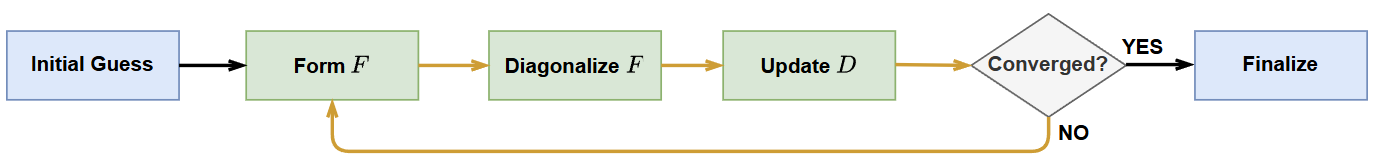

As an example, let us write a program to optimize the Hatree–Fock wave function and apply it to water.

**Setting things up**

In [ ]:
h2o_xyz = """3
water
O        0.0000000000      0.0000000000      0.0000000000                 
H        0.6891400000      0.8324710000      0.0000000000                 
H        0.7224340000     -0.8726890000      0.0000000000
"""

molecule = vlx.Molecule.from_xyz_string(h2o_xyz)
basis = vlx.MolecularBasis.read(molecule, "cc-pvdz")

In [ ]:
molecule.show()

In [ ]:
norb = basis.get_dimension_of_basis()
nocc = molecule.number_of_alpha_electrons()
V_nuc = molecule.nuclear_repulsion_energy()

print("Number of contracted basis functions:", norb)
print("Number of doubly occupied molecular orbitals:", nocc)
print(f"Nuclear repulsion energy (in a.u.): {V_nuc : 14.12f}")

**Integrals in AO basis**

In [ ]:
# overlap matrix
S = vlx.compute_overlap_integrals(molecule, basis)
T = vlx.compute_kinetic_energy_integrals(molecule, basis)
V = vlx.compute_nuclear_potential_integrals(molecule, basis)

h = T + V

fock_drv = vlx.FockDriver()
g = fock_drv.compute_eri(molecule, basis)

### SCF procedure

---

Set the maximum number of iterations and convergence threshold.

In [ ]:
max_iter = 50
conv_thresh = 1e-4

#### Starting guess

In [ ]:
def density_initial_guess(method=None):

    if method == "sad":  # superposition of atomic densities
        D = np.zeros((norb, norb))
        D[0, 0] = 2.0  # O 1s
        D[1, 1] = 2.0  # O 2s
        D[3, 3] = 1.0  # H 1s
        D[5, 5] = 1.0  # H 1s
        D[7, 7] = 4.0 / 3  # O 2py
        D[11, 11] = 4.0 / 3  # O 2pz
        D[15, 15] = 4.0 / 3  # O 2px

    else:
        epsilon, C = scipy.linalg.eigh(h, S)  # initial guess
        D = 2 * np.einsum("ai,bi->ab", C[:, :nocc], C[:, :nocc])

    return D

#### Error vector

As a measure of convergence, we adopt the norm of the occupied–unoccipied block of the Fock matrix in MO basis. It is convenient to scatter the elements of this block into the format of a vector and which we refer to as the *error vector* and use its norm as criterion of convergence.

#### SCF iterations

In [ ]:
print("iter      SCF energy    Error norm")

D = density_initial_guess()

for iter in range(max_iter):

    J = np.einsum("abcd,cd->ab", g, D)
    K = np.einsum("adcb,cd->ab", g, D)
    F = h + J - 0.5 * K

    E = 0.5 * np.einsum("ab,ab->", h + F, D) + V_nuc

    if iter == 0:
        print(f"{iter:>2d}  {E:16.8f}      ----")
    else:
        # compute convergence metric
        F_MO = np.einsum("ai,ab,bj->ij", C, F, C)
        e_vec = np.reshape(F_MO[:nocc, nocc:], -1)

        error = np.linalg.norm(e_vec)

        print(f"{iter:>2d}  {E:16.8f}  {error:10.2e}")

        if error < conv_thresh:
            print("SCF iterations converged!")
            break

    epsilon, C = scipy.linalg.eigh(F, S)
    D = 2 * np.einsum("ai,bi->ab", C[:, :nocc], C[:, :nocc])

#### Orbital energies

In [ ]:
print("Orbital energies (occ)  :", np.around(epsilon[:nocc], 6))

#### Check results

In [ ]:
scf_drv = vlx.ScfRestrictedDriver()
scf_results = scf_drv.compute(molecule, basis)

### Convergence

The Rothaan–Hall scheme for SCF optimization suffers from poor convergence. In practice, modifications are introduced:

- Initial guess based on a *superposition of atomic densities* (SAD)
- [Convergence acceleration](https://kthpanor.github.io/echem/hf-scf/#convergence-acceleration) using *direct inversion of iterative subspace* (DIIS)

# <font color="green">Summary</font>

- The energy minimization for a multielectron wave function of the form of a Slater determinant leads to an effective one-particle eigenvalue problem introducing the Fock operator

- The Fock operator depends on its eigenfunctions and calls for a self-consistent field procedure

- The SCF solution is known as the Hartree–Fock state